# 인프라 기반 클러스터링 분석

지역별 인프라 시설 접근성 점수를 바탕으로 클러스터링 분석을 수행합니다.  
엘보우 방식을 이용해 최적의 클러스터 수를 결정하며, 각 클러스터의 인프라 특성을 시각화합니다.

## 1.라이브러리 설치 및 환경 설정
필요한 라이브러리를 설치하고, matplotlib 한글 폰트를 설정합니다.


In [ ]:
# 필수 라이브러리 설치
!pip install koreanize_matplotlib factor_analyzer yellowbrick
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import koreanize_matplotlib

# 한글 폰트 설정
from matplotlib import rc
if platform.system() == 'Windows':
    font_name = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    font_name = 'AppleGothic'
else:
    font_name = 'NanumGothic'
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 989.6 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 31.5 MB/s eta 0:00:00
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=9b61d1354eaedb8ed6f84104ff5471a5594aa604e074028701337ab7b33a75b3
  Stored in directory: /root/.cache/pip/wheels/fa/f7/53/a55a8a56668a6fe0199e0e02b6e0ae3007ec35cdf6e4c25df7
Successfully built factor_analyzer


## 2.데이터 로드 및 전처리
CSV 데이터를 불러오고 주소 컬럼을 분리한 뒤, 표준화를 수행합니다.


In [18]:
# 코랩 전용
from google.colab import drive

drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/비어플/dataset")
print("현재 작업 디렉토리:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
현재 작업 디렉토리: /content/drive/MyDrive/비어플/dataset


In [19]:
# CSV 파일 경로는 환경에 따라 수정 (예: Google Drive 연동 시 경로 주의)
data = pd.read_csv('facility_total_scores.csv', encoding='utf-8-sig')

# 주소 컬럼 분리
address = data['address']
data = data.drop(columns=['address'])

# 표준화
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)


## 3.인프라 변수의 의미 기반 차원 축소
유사 인프라 지표들을 도메인 기반으로 분류하여 평균 처리함으로써 수동 차원 축소를 수행하고, 분석 효율을 높입니다.


In [20]:
# 인프라 카테고리별 총점 컬럼 구성

infra_categories = {
    "농업_지원": ['농업기술센터_total_score', '농기계대여소_total_score', '농산물직거래판매장_total_score'],
    "농업_매물": ['농지매물_total_score'],
    "교통":     ['기차역_total_score', '버스정류장_total_score', '고속버스터미널_total_score'],
    "교육":     ['초중학교_total_score', '학원_total_score'],
    "편의":     ['편의점_total_score', '시장_total_score', '은행_total_score', '차량정비소_total_score'],
    "서비스":   ['병원_total_score', '우체국_total_score', '경찰서_total_score', '행정복지센터_total_score'],
}

# 카테고리별 평균 점수를 계산한 데이터프레임 생성
infra_data = pd.DataFrame()
for category, cols in infra_categories.items():
    infra_data[category] = scaled_data[cols].mean(axis=1)


## 4.클러스터 수 결정 (엘보우 방식)
Elbow Method를 사용하여 최적의 클러스터 수를 시각적으로 결정합니다.


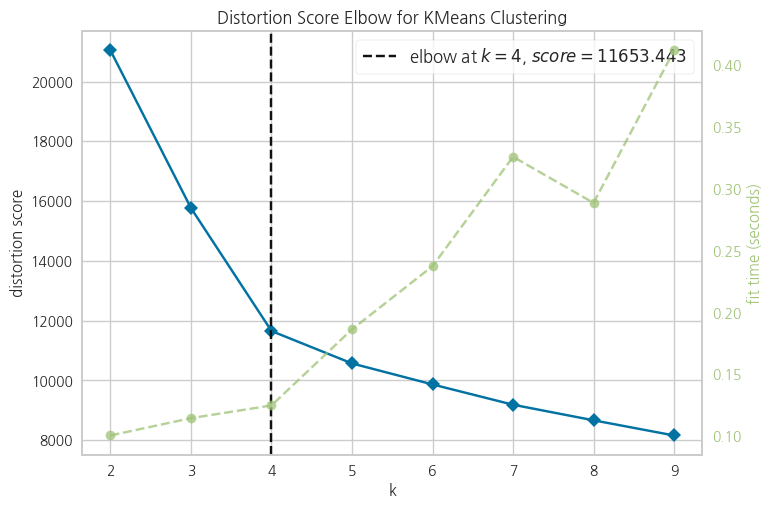

선택된 클러스터 수: 4


In [21]:
model = KMeans(random_state=42, n_init=20)
visualizer = KElbowVisualizer(model, k=(2, 10))
visualizer.fit(infra_data)
visualizer.show()

# 최적 k 자동 추출 가능
optimal_k = visualizer.elbow_value_
print("선택된 클러스터 수:", optimal_k)

## 5.클러스터링 수행
KMeans를 통해 클러스터링을 수행하고, 각 데이터에 클러스터 라벨을 부여합니다.


In [22]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
infra_data_km = infra_data.copy()
infra_data_km['cluster'] = kmeans.fit_predict(infra_data)

In [23]:
# 색상 매핑
cluster_colors = {
    0: "#3B4CC0",  # 파랑
    1: "#4CAF50",  # 초록
    2: "#F44336",  # 빨강
    3: "#9C27B0",  # 보라
}

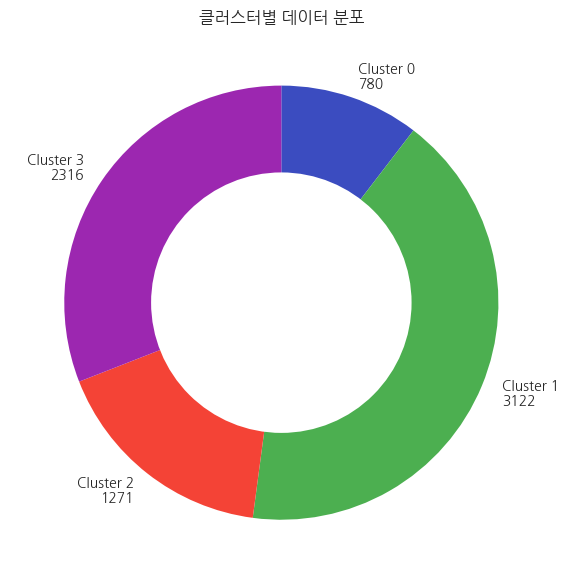

In [24]:
# 클러스터별 데이터 수 시각화 (도넛 차트)
cluster_counts = infra_data_km['cluster'].value_counts().sort_index()
colors = [cluster_colors.get(i, "#333333") for i in cluster_counts.index]

plt.figure(figsize=(6, 6))
wedges, texts = plt.pie(cluster_counts,
                        labels=[f"Cluster {i}\n{v}" for i, v in cluster_counts.items()],
                        startangle=90, counterclock=False,
                        colors=colors)
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("클러스터별 데이터 분포")
plt.tight_layout()
plt.show()


## 6.클러스터별 데이터 분포 확인
각 클러스터의 데이터 수를 도넛 차트로 시각화하고, 클러스터별 변수 분포를 확인합니다.


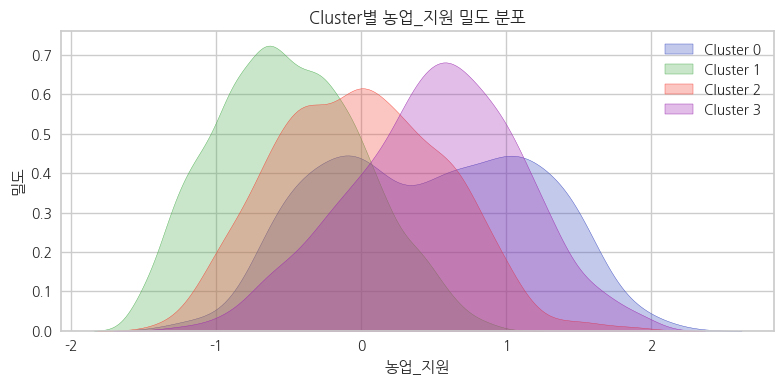

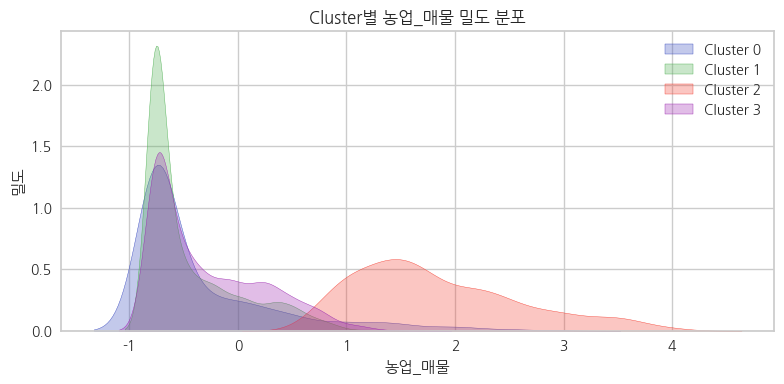

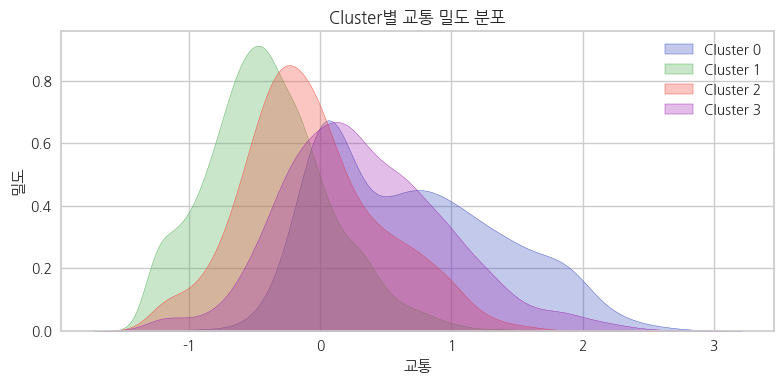

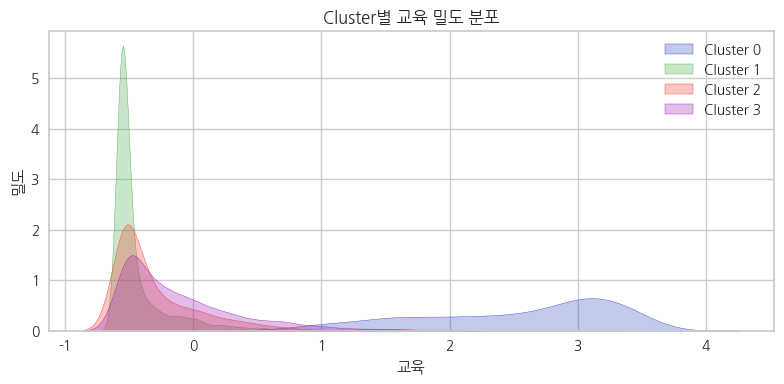

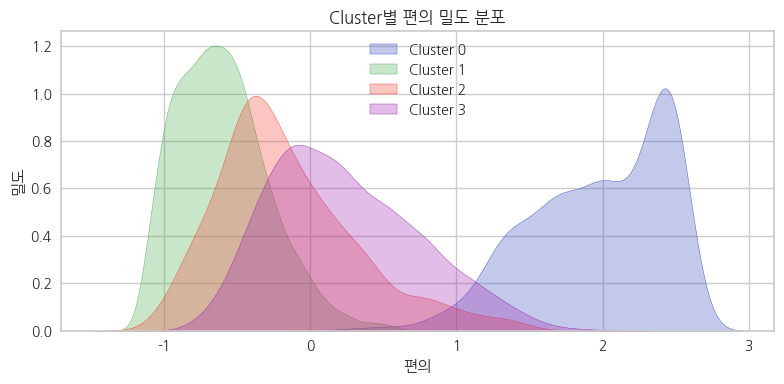

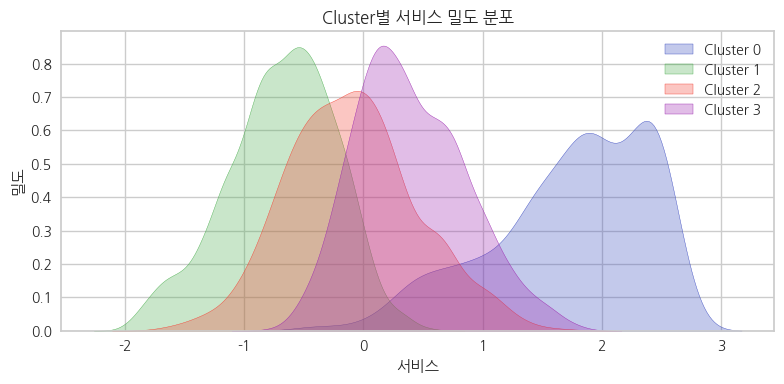

In [25]:
variables = [col for col in infra_data_km.columns if col != 'cluster']
clusters = sorted(infra_data_km['cluster'].unique())

for var in variables:
    plt.figure(figsize=(8, 4))

    for cl in clusters:
        subset = infra_data_km[infra_data_km['cluster'] == cl]
        sns.kdeplot(
            subset[var],
            label=f'Cluster {cl}',
            fill=True,
            alpha=0.3,
            color=cluster_colors.get(cl, "#333333")
        )

    plt.title(f'Cluster별 {var} 밀도 분포')
    plt.xlabel(var)
    plt.ylabel('밀도')
    plt.legend()
    plt.tight_layout()
    # plt.savefig(f'{var}_cluster_density.png', dpi=300, bbox_inches='tight')
    plt.show()


## 7.클러스터별 평균 특성 분석
카테고리별 평균값을 정규화하여 막대그래프 및 선그래프로 비교합니다.

In [26]:
# 클러스터별 평균값 계산
cluster_means = [
    infra_data_km.query(f"cluster=={i}")
                 .drop(columns="cluster")
                 .mean()
                 .reset_index(name=f"cluster_{i}")
    for i in range(optimal_k)
]

df_cluster_means = pd.concat(cluster_means, axis=1)
df_cluster_means = df_cluster_means.loc[:, ~df_cluster_means.columns.duplicated()]

# 인프라 종류를 인덱스로 설정
df_plot = df_cluster_means.set_index("index")

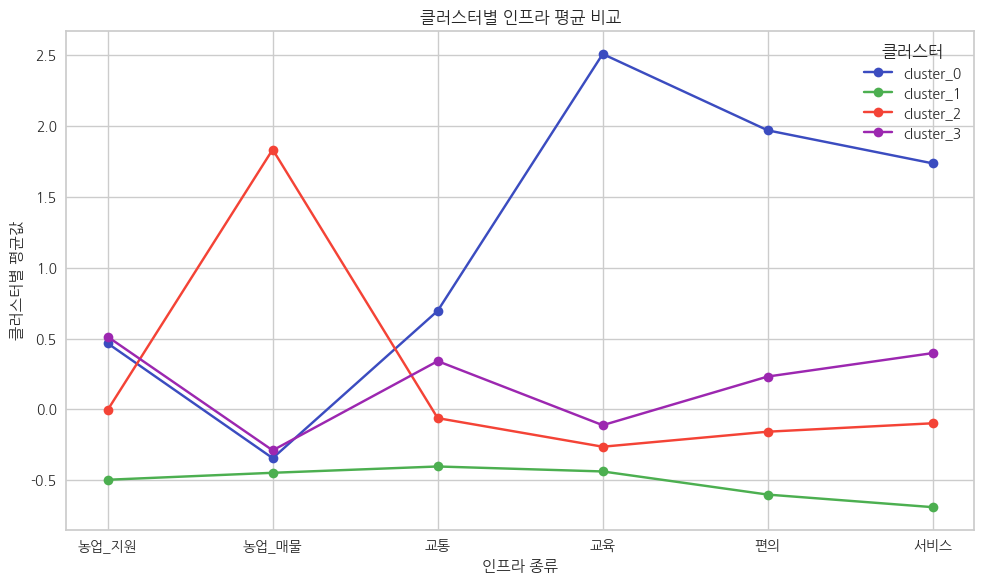

In [27]:
plt.figure(figsize=(10, 6))

for col in df_plot.columns:
    clust_num = int(col.replace("cluster_", ""))
    plt.plot(
        df_plot.index,
        df_plot[col],
        marker='o',
        label=col,
        color=cluster_colors.get(clust_num, "#333333")
    )

plt.xlabel("인프라 종류")
plt.ylabel("클러스터별 평균값")
plt.title("클러스터별 인프라 평균 비교")
plt.legend(title="클러스터")
plt.grid(True)
plt.tight_layout()
plt.savefig("cluster_lineplot.png", dpi=300, bbox_inches='tight')  # 🔒 저장
plt.show()


## 8.결과 저장
분석 결과를 CSV로 저장하고, 원본 파일과 병합된 결과도 별도로 저장합니다.


In [28]:
#  결과 저장
infra_data_km = pd.concat([address, infra_data_km], axis=1)
infra_data_km.to_csv('infra_category_clustered.csv', index=False, encoding='utf-8-sig')

raw = pd.read_csv('facility_total_scores.csv', encoding='utf-8-sig')
raw['cluster'] = infra_data_km['cluster']
raw.to_csv('facility_total_scores_with_clusters.csv', index=False, encoding='utf-8-sig')